In [40]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent
from sac.utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [41]:
env_name = "Pendulum-v1"
env = gym.make(env_name)

In [42]:
render = False
log_interval = 20           # print avg reward in the interval
new_episodes = 40 # max training episodes
max_timesteps = 2000   
save_interval = 500

In [ ]:
params = SB3_PARAMS
params["alpha"] = 0.1
params["entropy"] = -1
params["lr"] = 1e-4

In [44]:
random_seed = 0

In [45]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [46]:
hidden_sizes = [128, 128]
action_bounds = (env.action_space.low, env.action_space.high)
obs_dim = env.observation_space.shape[0]
sac = from_dict(hidden_sizes=hidden_sizes, obs_dim=obs_dim, action_bounds=action_bounds, **params)

In [47]:
agent = sac
agent_name = "SAC"

In [48]:
filepath = f"./results2/{agent_name}-{env_name}-{random_seed}"

In [49]:
warmup_agent(agent, env, 256, max_timesteps)

In [50]:
losses = []
rewards = []
lengths = []
i_episode = 0

In [51]:
losses, rewards, lengths, i_episode, alphas = train_agent(agent, env, i_episode, new_episodes, max_timesteps, filepath, losses, rewards, lengths, log_interval=1, save_interval=20, train_interval=1)

Episode 1 	 avg length: 200 	 reward: -1395.1540170209769
Episode 2 	 avg length: 200 	 reward: -1185.041291713936
Episode 3 	 avg length: 200 	 reward: -1200.008910047287
Episode 4 	 avg length: 200 	 reward: -1392.890942535777
Episode 5 	 avg length: 200 	 reward: -1087.029458156532
Episode 6 	 avg length: 200 	 reward: -1094.802369835889
Episode 7 	 avg length: 200 	 reward: -1320.267361891488
Episode 8 	 avg length: 200 	 reward: -967.3747382707576
Episode 9 	 avg length: 200 	 reward: -1208.2498118766093
Episode 10 	 avg length: 200 	 reward: -1186.129029895762
Episode 11 	 avg length: 200 	 reward: -1168.2884473618583
Episode 12 	 avg length: 200 	 reward: -1121.5217182711544
Episode 13 	 avg length: 200 	 reward: -938.3181594555512
Episode 14 	 avg length: 200 	 reward: -920.1077548178125
Episode 15 	 avg length: 200 	 reward: -507.7677138011627
Episode 16 	 avg length: 200 	 reward: -130.59336449980336
Episode 17 	 avg length: 200 	 reward: -122.74858601991009
Episode 18 	 avg 

In [ ]:
rewards, lengths, losses = load_stats(filepath) 

In [52]:
from sac.plots import *

In [53]:
plot_path = "plots3"

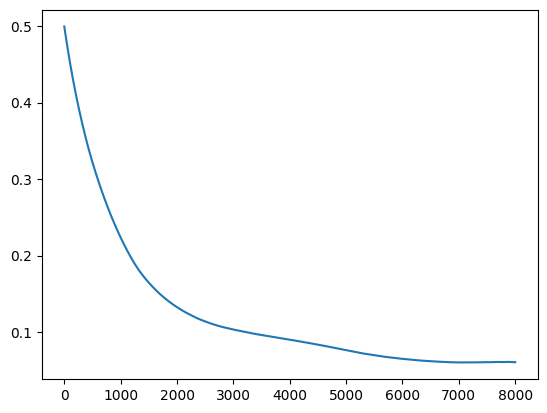

In [54]:
plt.plot(alphas)
plt.savefig(f"plots3/alphas_0.5_1_3.png")

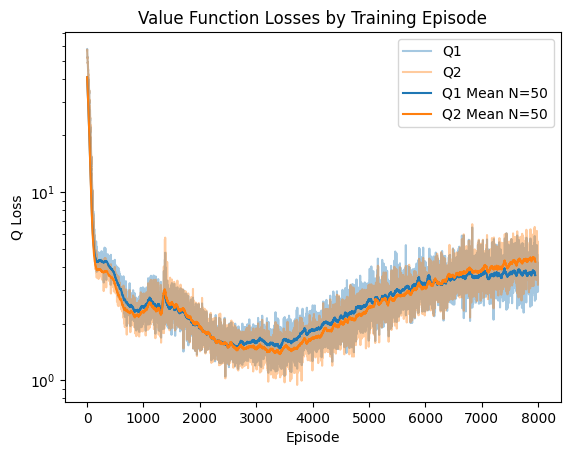

In [55]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

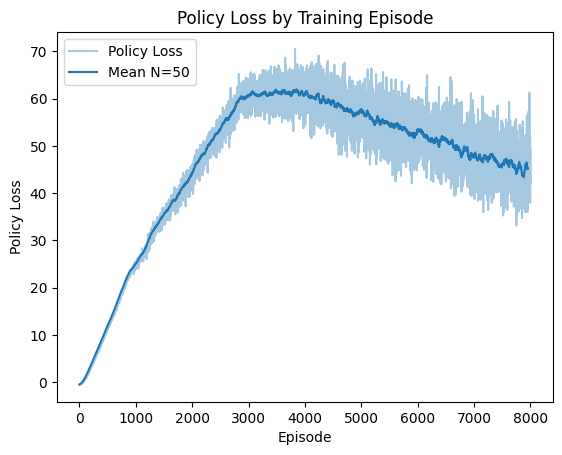

In [56]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

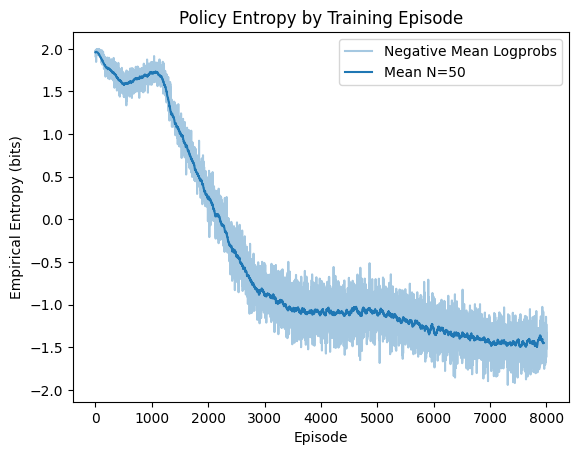

In [57]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)

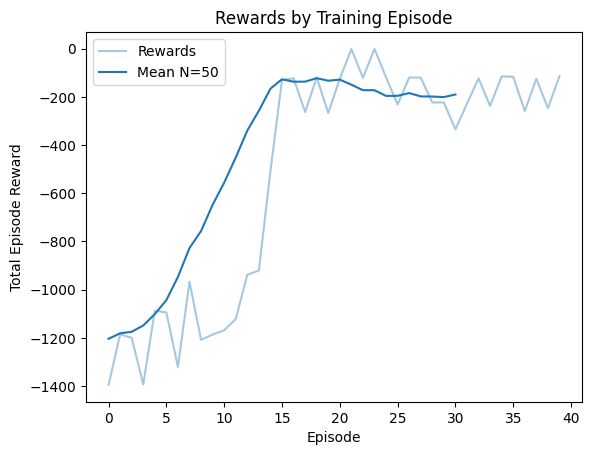

In [58]:
plot_rewards(rewards, plot_path, 10)